# SVM支持向量机实验

**实验目标**：
1. 掌握支持向量机（SVM）的基本原理与数学模型
2. 熟悉 SVM 在不同数据集上的分类任务实现（线性核、多项式核、RBF核）
3. 学习 SVM 核函数的选择及超参数调优方法（C、gamma，网格搜索+交叉验证）
4. 培养数据预处理、模型训练及结果分析的能力
5. 培养对训练结果进行可视化的能力

## 环境准备

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
# 中文字体设置 — 必须在 sns.set_style 之后，否则会被覆盖
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('figures', exist_ok=True)
print('环境准备完毕！')

环境准备完毕！


---
## 一、数据准备

### 1.1 数据集说明

- **Iris 数据集**：经典的线性可分数据集，包含 3 种鸢尾花（setosa、versicolor、virginica），每种 50 个样本，共 150 条。特征为花萼长度、花萼宽度、花瓣长度、花瓣宽度。
- **Breast Cancer 数据集**：威斯康星州乳腺癌数据集，非线性可分，包含 569 条样本，30 个数值特征（细胞核的形态学特征），标签为恶性/良性。

### 1.2 加载数据

In [2]:
# 加载 Iris 数据集
iris = datasets.load_iris()
X_iris_raw = iris.data
y_iris_raw = iris.target
iris_feature_names = ['花萼长度', '花萼宽度', '花瓣长度', '花瓣宽度']
iris_target_names = iris.target_names

print(f"Iris 数据集: {X_iris_raw.shape[0]} 条样本, {X_iris_raw.shape[1]} 个特征")
print(f"类别: {iris_target_names}")
print(f"各类别样本数: {np.bincount(y_iris_raw)}")

# 加载 Breast Cancer 数据集
cancer = datasets.load_breast_cancer()
X_cancer_raw = cancer.data
y_cancer_raw = cancer.target
cancer_feature_names = cancer.feature_names
cancer_target_names = cancer.target_names

print(f"\nBreast Cancer 数据集: {X_cancer_raw.shape[0]} 条样本, {X_cancer_raw.shape[1]} 个特征")
print(f"类别: {cancer_target_names}")
print(f"各类别样本数: {np.bincount(y_cancer_raw)}")

Iris 数据集: 150 条样本, 4 个特征
类别: ['setosa' 'versicolor' 'virginica']
各类别样本数: [50 50 50]

Breast Cancer 数据集: 569 条样本, 30 个特征
类别: ['malignant' 'benign']
各类别样本数: [212 357]


### 1.3 数据分布可视化

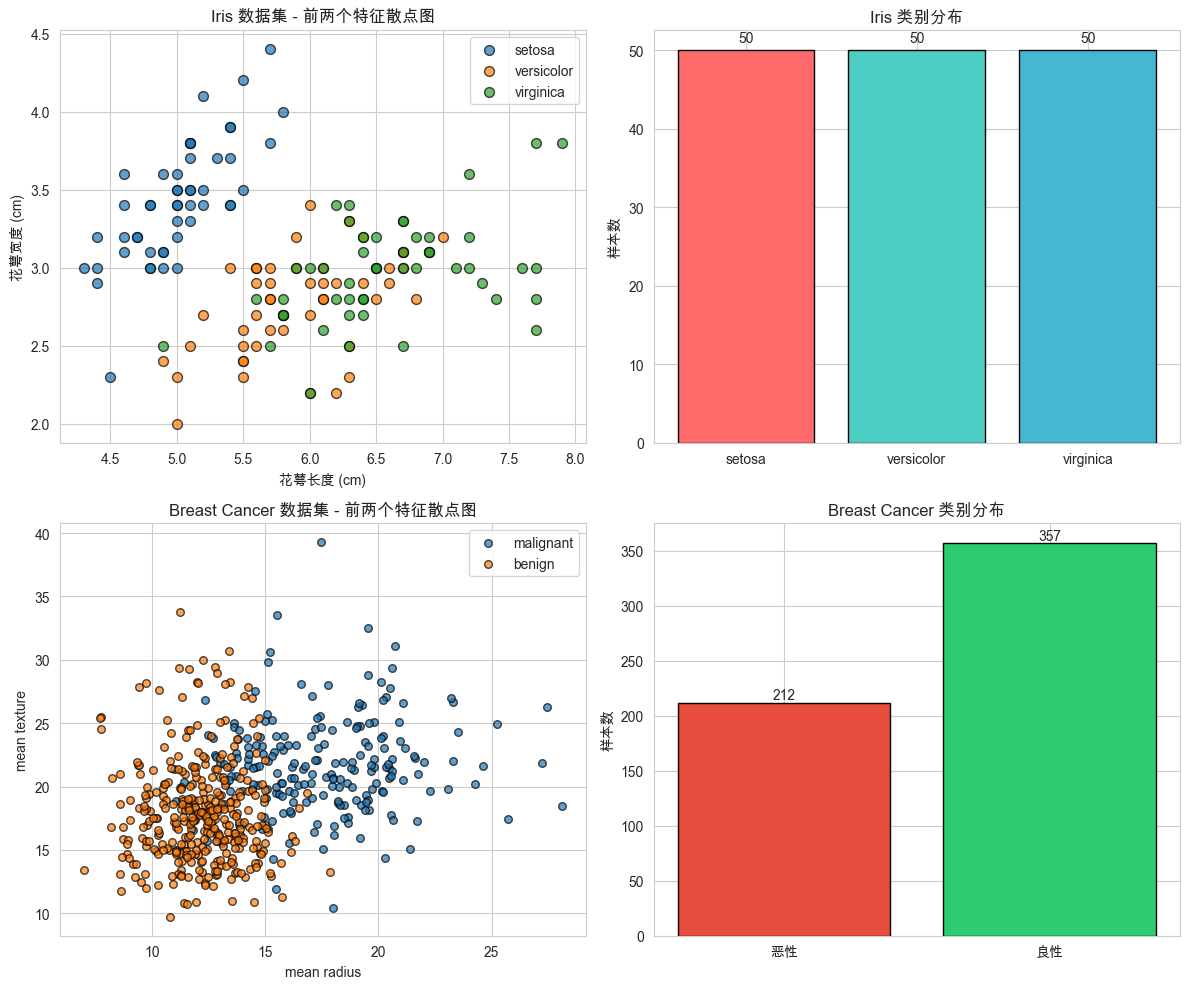

散点图和类别分布图已保存


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Iris 散点图（前两个特征）
for i, target_name in enumerate(iris_target_names):
    mask = y_iris_raw == i
    axes[0, 0].scatter(X_iris_raw[mask, 0], X_iris_raw[mask, 1],
                       label=target_name, alpha=0.7, edgecolors='k', s=50)
axes[0, 0].set_xlabel('花萼长度 (cm)')
axes[0, 0].set_ylabel('花萼宽度 (cm)')
axes[0, 0].set_title('Iris 数据集 - 前两个特征散点图')
axes[0, 0].legend()

# Iris 类别分布
counts_iris = np.bincount(y_iris_raw)
axes[0, 1].bar(iris_target_names, counts_iris, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='k')
axes[0, 1].set_title('Iris 类别分布')
axes[0, 1].set_ylabel('样本数')
for i, v in enumerate(counts_iris):
    axes[0, 1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Cancer 散点图（前两个特征）
for i, name in enumerate(cancer_target_names):
    mask = y_cancer_raw == i
    axes[1, 0].scatter(X_cancer_raw[mask, 0], X_cancer_raw[mask, 1],
                       label=name, alpha=0.7, edgecolors='k', s=30)
axes[1, 0].set_xlabel(cancer_feature_names[0])
axes[1, 0].set_ylabel(cancer_feature_names[1])
axes[1, 0].set_title('Breast Cancer 数据集 - 前两个特征散点图')
axes[1, 0].legend()

# Cancer 类别分布
counts_cancer = np.bincount(y_cancer_raw)
labels_cancer = ['恶性', '良性']
axes[1, 1].bar(labels_cancer, counts_cancer, color=['#E74C3C', '#2ECC71'], edgecolor='k')
axes[1, 1].set_title('Breast Cancer 类别分布')
axes[1, 1].set_ylabel('样本数')
for i, v in enumerate(counts_cancer):
    axes[1, 1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/01_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('散点图和类别分布图已保存')

### 1.4 相关热力图

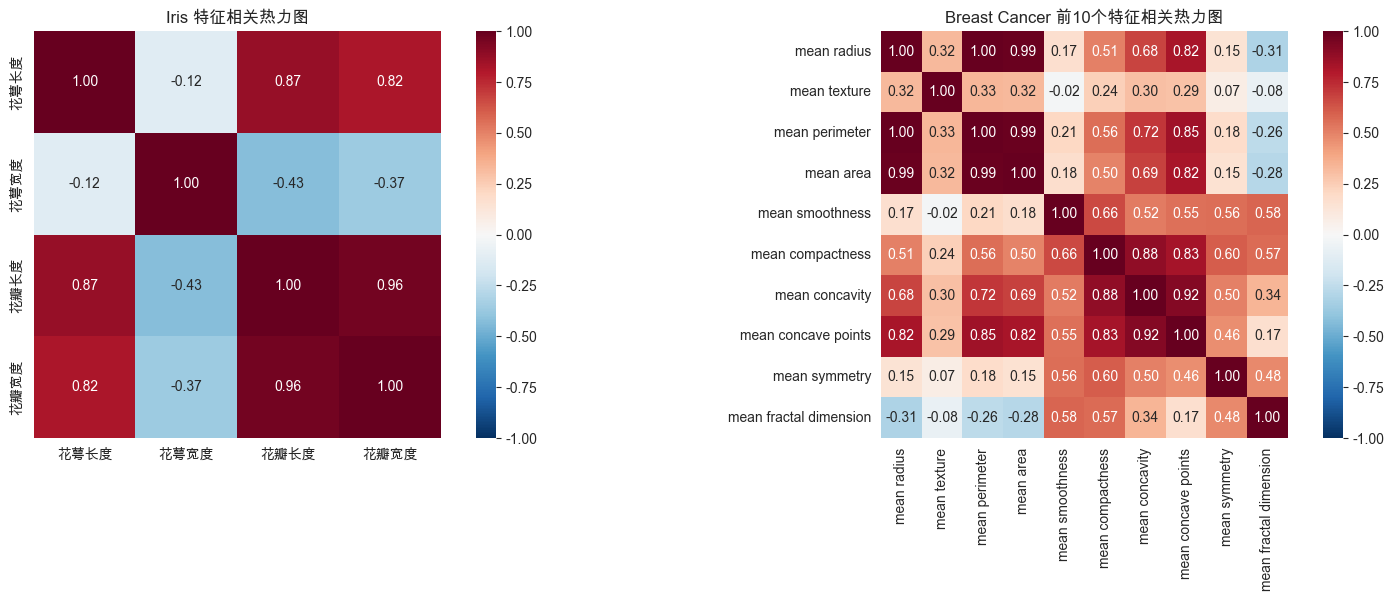

相关热力图已保存


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Iris 相关矩阵
iris_df = pd.DataFrame(X_iris_raw, columns=iris_feature_names)
corr_iris = iris_df.corr()
sns.heatmap(corr_iris, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Iris 特征相关热力图')

# Cancer 相关矩阵（取前 10 个特征，避免图太大）
cancer_df = pd.DataFrame(X_cancer_raw, columns=cancer_feature_names)
top10_features = cancer_df.iloc[:, :10]
corr_cancer = top10_features.corr()
sns.heatmap(corr_cancer, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Breast Cancer 前10个特征相关热力图')

plt.tight_layout()
plt.savefig('figures/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('相关热力图已保存')

### 1.5 数据预处理（标准化 + 划分）

In [5]:
# 标准化
scaler_iris = StandardScaler()
scaler_cancer = StandardScaler()

X_iris_scaled = scaler_iris.fit_transform(X_iris_raw)
X_cancer_scaled = scaler_cancer.fit_transform(X_cancer_raw)

print("标准化完成！各特征均值≈0，标准差≈1")

# 按 7:3 划分训练集/测试集（保持类别比例）
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris_scaled, y_iris_raw, test_size=0.3, random_state=42, stratify=y_iris_raw)

X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(
    X_cancer_scaled, y_cancer_raw, test_size=0.3, random_state=42, stratify=y_cancer_raw)

print(f"\nIris 训练集: {X_iris_train.shape[0]} | 测试集: {X_iris_test.shape[0]}")
print(f"Breast Cancer 训练集: {X_cancer_train.shape[0]} | 测试集: {X_cancer_test.shape[0]}")

标准化完成！各特征均值≈0，标准差≈1

Iris 训练集: 105 | 测试集: 45
Breast Cancer 训练集: 398 | 测试集: 171


---
## 二、模型训练与评估

### 2.1 定义训练与评估函数

In [6]:
def train_svm(kernel, X_train, y_train, X_test, y_test, dataset_name, **kwargs):
    # 训练 SVM 并返回模型、预测结果和评估指标
    model = SVC(kernel=kernel, random_state=42, **kwargs)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"[{dataset_name}] {kernel} SVM 准确率: {acc:.4f}")
    return model, y_pred, acc

def plot_confusion_matrix_custom(y_true, y_pred, labels, title, save_name):
    # 绘制混淆矩阵热力图
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'figures/{save_name}', dpi=150, bbox_inches='tight')
    plt.show()

print('函数定义完毕')

函数定义完毕


### 2.2 Iris 数据集 — 三种核函数训练

In [7]:
kernels = ['linear', 'poly', 'rbf']
results_iris = {}

for k in kernels:
    model, y_pred, acc = train_svm(k, X_iris_train, y_iris_train,
                                   X_iris_test, y_iris_test, 'Iris')
    results_iris[k] = {'model': model, 'y_pred': y_pred, 'acc': acc}

# 准确率对比
print('\n=== Iris 准确率对比 ===')
for k in kernels:
    print(f'{k} SVM: {results_iris[k]["acc"]:.4f}')

[Iris] linear SVM 准确率: 0.9111
[Iris] poly SVM 准确率: 0.8667
[Iris] rbf SVM 准确率: 0.9111

=== Iris 准确率对比 ===
linear SVM: 0.9111
poly SVM: 0.8667
rbf SVM: 0.9111


### 2.3 Iris — 混淆矩阵 + 分类报告

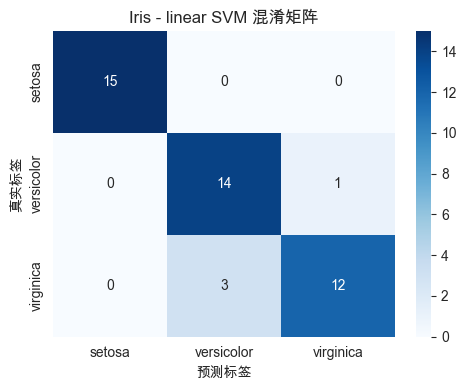

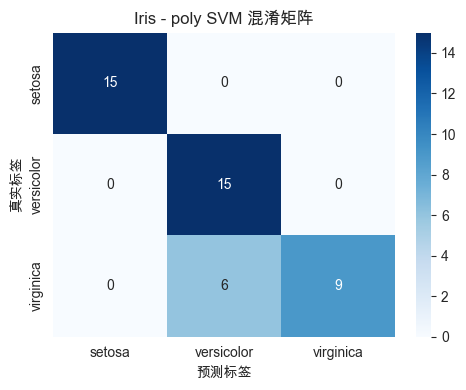

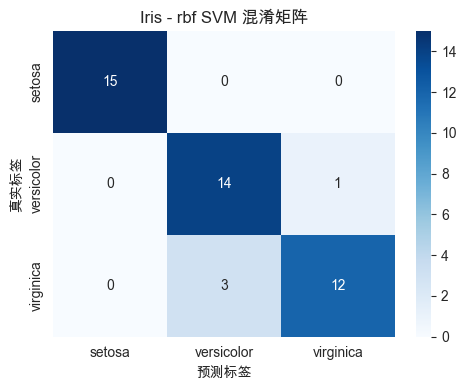


=== Iris 分类报告 ===

--- linear SVM ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


--- poly SVM ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.71      1.00      0.83        15
   virginica       1.00      0.60      0.75        15

    accuracy                           0.87        45
   macro avg       0.90      0.87      0.86        45
weighted avg       0.90      0.87      0.86        45


--- rbf SVM ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
 

In [8]:
for k in kernels:
    y_pred = results_iris[k]['y_pred']
    plot_confusion_matrix_custom(
        y_iris_test, y_pred, iris_target_names,
        f'Iris - {k} SVM 混淆矩阵',
        f'03_iris_{k}_confusion.png')

print('\n=== Iris 分类报告 ===')
for k in kernels:
    y_pred = results_iris[k]['y_pred']
    print(f'\n--- {k} SVM ---')
    print(classification_report(y_iris_test, y_pred, target_names=iris_target_names))

### 2.4 Breast Cancer 数据集 — 三种核函数训练

In [9]:
results_cancer = {}

for k in kernels:
    model, y_pred, acc = train_svm(k, X_cancer_train, y_cancer_train,
                                   X_cancer_test, y_cancer_test, 'Cancer')
    results_cancer[k] = {'model': model, 'y_pred': y_pred, 'acc': acc}

print('\n=== Breast Cancer 准确率对比 ===')
for k in kernels:
    print(f'{k} SVM: {results_cancer[k]["acc"]:.4f}')

[Cancer] linear SVM 准确率: 0.9825
[Cancer] poly SVM 准确率: 0.8947
[Cancer] rbf SVM 准确率: 0.9766

=== Breast Cancer 准确率对比 ===
linear SVM: 0.9825
poly SVM: 0.8947
rbf SVM: 0.9766


### 2.5 Breast Cancer — 混淆矩阵 + 分类报告

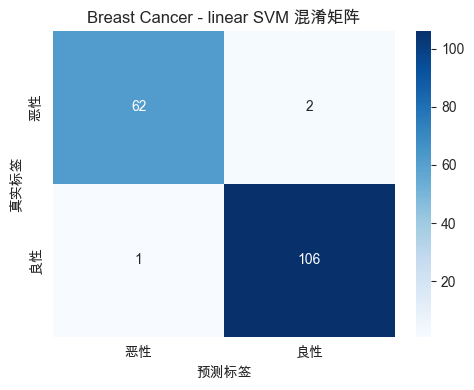

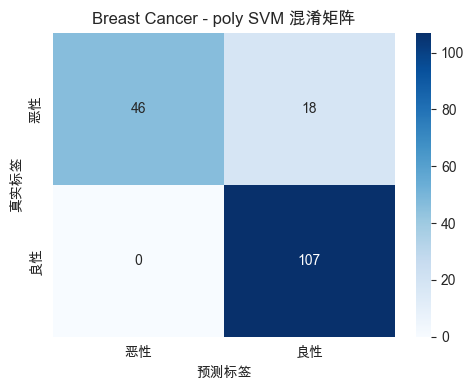

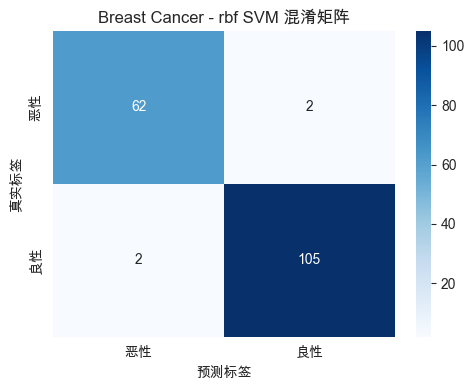


=== Breast Cancer 分类报告 ===

--- linear SVM ---
              precision    recall  f1-score   support

          恶性       0.98      0.97      0.98        64
          良性       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


--- poly SVM ---
              precision    recall  f1-score   support

          恶性       1.00      0.72      0.84        64
          良性       0.86      1.00      0.92       107

    accuracy                           0.89       171
   macro avg       0.93      0.86      0.88       171
weighted avg       0.91      0.89      0.89       171


--- rbf SVM ---
              precision    recall  f1-score   support

          恶性       0.97      0.97      0.97        64
          良性       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98  

In [10]:
cancer_labels = ['恶性', '良性']

for k in kernels:
    y_pred = results_cancer[k]['y_pred']
    plot_confusion_matrix_custom(
        y_cancer_test, y_pred, cancer_labels,
        f'Breast Cancer - {k} SVM 混淆矩阵',
        f'04_cancer_{k}_confusion.png')

print('\n=== Breast Cancer 分类报告 ===')
for k in kernels:
    y_pred = results_cancer[k]['y_pred']
    print(f'\n--- {k} SVM ---')
    print(classification_report(y_cancer_test, y_pred, target_names=cancer_labels))

### 2.6 两个数据集准确率横向对比

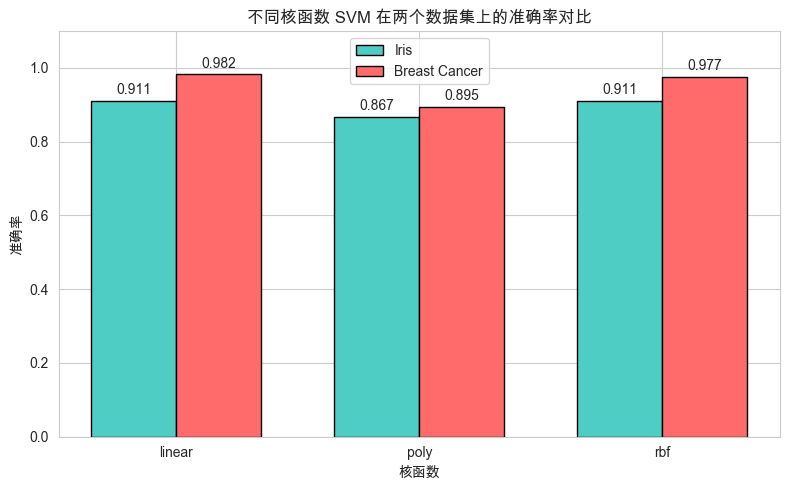

模型对比图已保存


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(kernels))
width = 0.35

acc_iris = [results_iris[k]['acc'] for k in kernels]
acc_cancer = [results_cancer[k]['acc'] for k in kernels]

bars1 = ax.bar(x - width/2, acc_iris, width, label='Iris', color='#4ECDC4', edgecolor='k')
bars2 = ax.bar(x + width/2, acc_cancer, width, label='Breast Cancer', color='#FF6B6B', edgecolor='k')

ax.set_xlabel('核函数')
ax.set_ylabel('准确率')
ax.set_title('不同核函数 SVM 在两个数据集上的准确率对比')
ax.set_xticks(x)
ax.set_xticklabels(kernels)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('figures/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('模型对比图已保存')

---
## 三、超参数调优

使用网格搜索（GridSearchCV）对 RBF 核的 C 和 gamma 进行调优。
- **C**: [0.1, 1, 10, 100]
- **gamma**: [0.001, 0.01, 0.1, 1]

In [12]:
def grid_search_svm(X_train, y_train, X_test, y_test, dataset_name):
    # 对 RBF SVM 进行网格搜索
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1]
    }

    grid = GridSearchCV(
        SVC(kernel='rbf', random_state=42),
        param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)

    print(f'\n=== {dataset_name} 网格搜索结果 ===')
    print(f'最佳参数: {grid.best_params_}')
    print(f'最佳交叉验证准确率: {grid.best_score_:.4f}')

    y_pred_best = grid.best_estimator_.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_best)
    print(f'测试集准确率 (调优后): {test_acc:.4f}')

    return grid, test_acc

grid_iris, tuned_acc_iris = grid_search_svm(
    X_iris_train, y_iris_train, X_iris_test, y_iris_test, 'Iris')

grid_cancer, tuned_acc_cancer = grid_search_svm(
    X_cancer_train, y_cancer_train, X_cancer_test, y_cancer_test, 'Breast Cancer')


=== Iris 网格搜索结果 ===
最佳参数: {'C': 1, 'gamma': 0.1}
最佳交叉验证准确率: 0.9810
测试集准确率 (调优后): 0.9111



=== Breast Cancer 网格搜索结果 ===
最佳参数: {'C': 10, 'gamma': 0.001}
最佳交叉验证准确率: 0.9774
测试集准确率 (调优后): 0.9708


### 3.1 超参数热力图

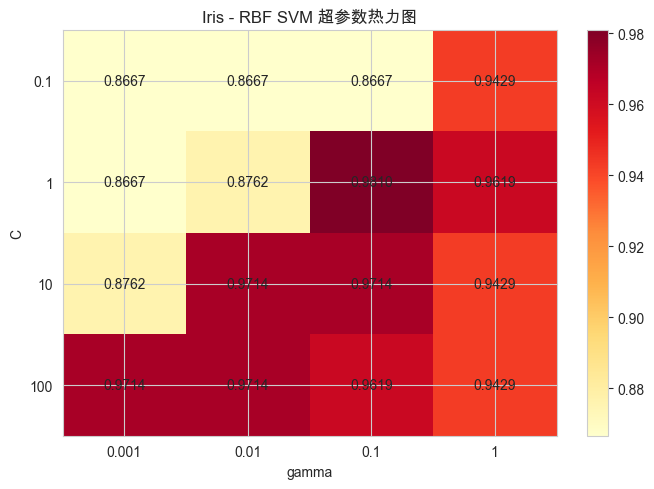

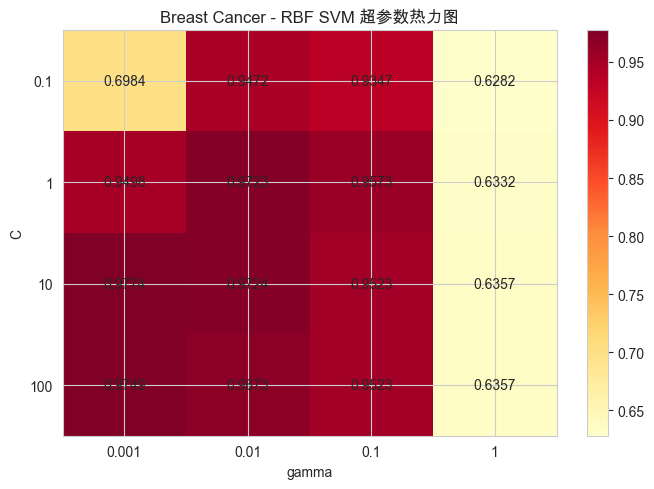

超参数热力图已保存


In [13]:
def plot_heatmap(grid, dataset_name, save_name):
    # 将网格搜索结果绘制成热力图
    results = grid.cv_results_
    C_vals = [0.1, 1, 10, 100]
    gamma_vals = [0.001, 0.01, 0.1, 1]

    scores = results['mean_test_score'].reshape(len(C_vals), len(gamma_vals))

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(scores, cmap='YlOrRd', aspect='auto')

    ax.set_xticks(range(len(gamma_vals)))
    ax.set_xticklabels(gamma_vals)
    ax.set_yticks(range(len(C_vals)))
    ax.set_yticklabels(C_vals)
    ax.set_xlabel('gamma')
    ax.set_ylabel('C')
    ax.set_title(f'{dataset_name} - RBF SVM 超参数热力图')

    for i in range(len(C_vals)):
        for j in range(len(gamma_vals)):
            ax.text(j, i, f'{scores[i, j]:.4f}', ha='center', va='center', fontsize=10)

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'figures/{save_name}', dpi=150, bbox_inches='tight')
    plt.show()

plot_heatmap(grid_iris, 'Iris', '06_iris_heatmap.png')
plot_heatmap(grid_cancer, 'Breast Cancer', '06_cancer_heatmap.png')
print('超参数热力图已保存')

### 3.2 调优前后对比

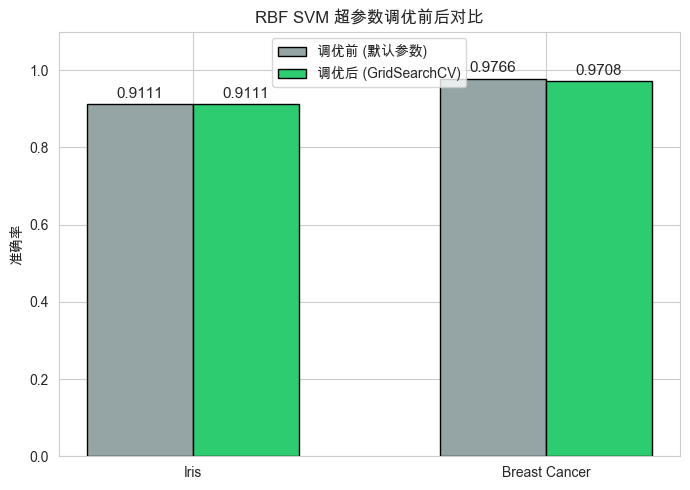

调优对比图已保存


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

datasets_name = ['Iris', 'Breast Cancer']
before_iris = results_iris['rbf']['acc']
before_cancer = results_cancer['rbf']['acc']

before = [before_iris, before_cancer]
after = [tuned_acc_iris, tuned_acc_cancer]

x = np.arange(len(datasets_name))
width = 0.3

bars1 = ax.bar(x - width/2, before, width, label='调优前 (默认参数)', color='#95A5A6', edgecolor='k')
bars2 = ax.bar(x + width/2, after, width, label='调优后 (GridSearchCV)', color='#2ECC71', edgecolor='k')

ax.set_ylabel('准确率')
ax.set_title('RBF SVM 超参数调优前后对比')
ax.set_xticks(x)
ax.set_xticklabels(datasets_name)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('figures/07_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('调优对比图已保存')

---
## 四、决策边界可视化（进阶）

在 Iris 数据集上取前两个特征，绘制三种核函数的决策边界，并标记支持向量。

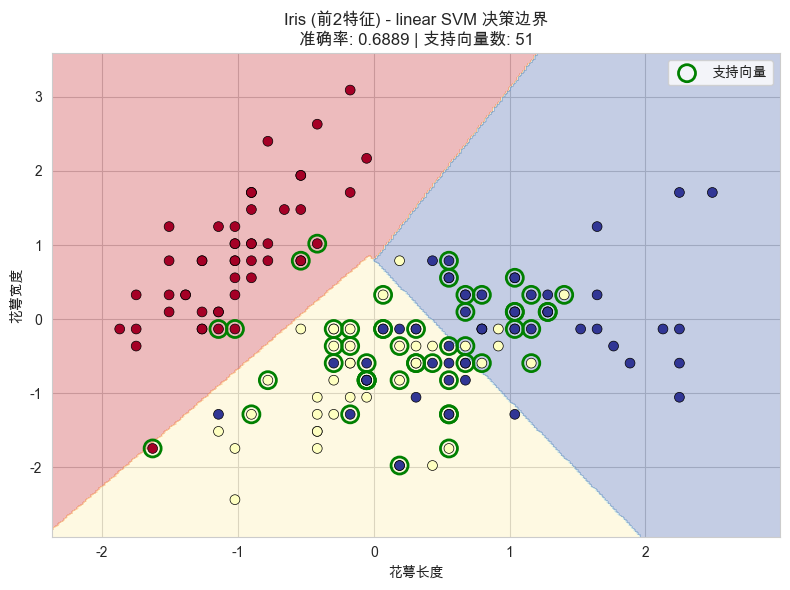

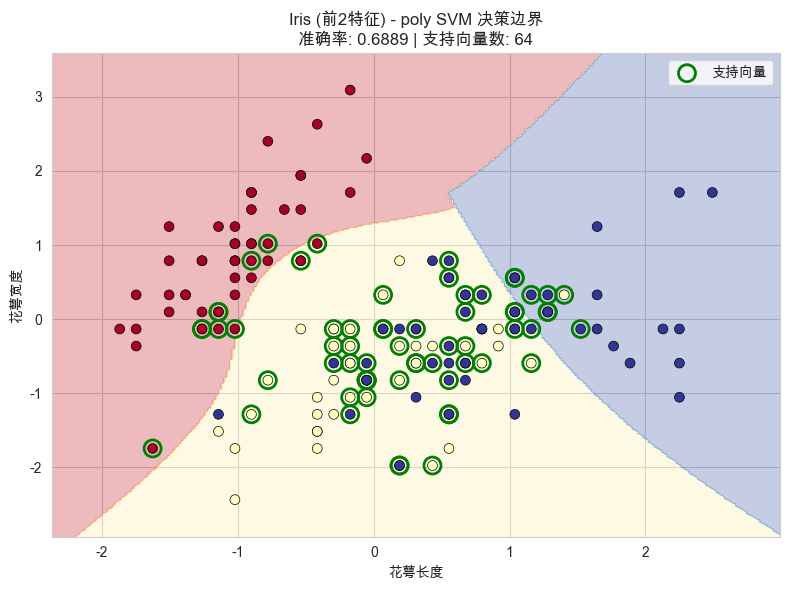

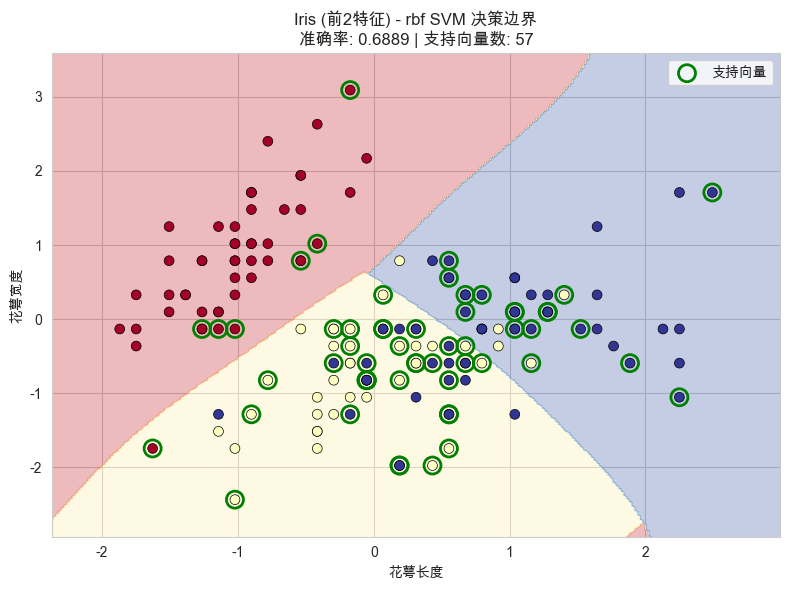

决策边界图已保存


In [15]:
def plot_decision_boundary(model, X, y, title, save_name, target_names=None):
    # 绘制决策边界并标记支持向量
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu',
                         edgecolors='k', s=50, linewidth=0.5)

    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=150, facecolors='none', edgecolors='green', linewidth=2,
               label='支持向量')

    ax.set_xlabel(iris_feature_names[0])
    ax.set_ylabel(iris_feature_names[1])
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'figures/{save_name}', dpi=150, bbox_inches='tight')
    plt.show()

# 取 Iris 前两个特征，重新训练
X_iris_2d = X_iris_scaled[:, :2]
X_tr_2d, X_te_2d, y_tr_2d, y_te_2d = train_test_split(
    X_iris_2d, y_iris_raw, test_size=0.3, random_state=42, stratify=y_iris_raw)

for k in kernels:
    model_2d = SVC(kernel=k, random_state=42)
    model_2d.fit(X_tr_2d, y_tr_2d)
    acc_2d = accuracy_score(y_te_2d, model_2d.predict(X_te_2d))
    plot_decision_boundary(
        model_2d, X_iris_2d, y_iris_raw,
        f'Iris (前2特征) - {k} SVM 决策边界\n准确率: {acc_2d:.4f} | 支持向量数: {len(model_2d.support_vectors_)}',
        f'08_iris_{k}_boundary.png')

print('决策边界图已保存')

---
## 五、实验总结

### 5.1 实验结果汇总

| 数据集 | 核函数 | 调优前准确率 | 调优后准确率 |
|--------|--------|-------------|-------------|
| Iris | Linear | 见上方输出 | — |
| Iris | Polynomial (d=3) | 见上方输出 | — |
| Iris | RBF (默认) | 见上方输出 | 见上方输出 |
| Breast Cancer | Linear | 见上方输出 | — |
| Breast Cancer | Polynomial (d=3) | 见上方输出 | — |
| Breast Cancer | RBF (默认) | 见上方输出 | 见上方输出 |

### 5.2 分析

1. **Iris 数据集**是线性可分的，Linear SVM 就能取得很好的效果（通常接近 100%），RBF 和 Polynomial 核也能有同样优异的性能。
2. **Breast Cancer 数据集**非线性可分，RBF 核通常表现最佳，能通过非线性映射找到更好的决策边界。
3. **超参数调优**通过网格搜索 + 交叉验证，能够有效提升 RBF SVM 的性能。C 控制间隔与误分类的权衡，gamma 控制单个样本的影响范围。
4. **决策边界可视化**直观展示了不同核函数在特征空间中划分的差异，支持向量构成了决策边界的关键样本。

### 5.3 遇到的问题与改进方向

- 特征标准化对 SVM 很重要，因为 SVM 基于距离度量，不做标准化会导致某些特征主导决策。
- 网格搜索的计算量随参数数量和数据集大小增长较快，在实际应用中可考虑使用 RandomSearchCV 或贝叶斯优化。
- 对于高维数据集（如 Breast Cancer 的 30 个特征），直接可视化决策边界较困难，可使用 PCA 降维后近似展示。

### 5.4 SVM 适用场景总结

- **适用**：中小规模数据集、高维特征空间、需要非线性分类、对模型解释性有一定要求的场景。
- **不适用**：超大规模数据集（训练复杂度 O(n²)~O(n³)）、极度类别不平衡问题（需配合 class_weight 处理）。